# Risk Metrics and Tail Risk Analysis

In this stage, we use return distributions and volatility forecasts to estimate financial risk.

Objectives:
1. Estimate Value at Risk (VaR)
2. Analyze downside tail risk
3. Compare BTC and SP500 risk profiles
4. Study risk behavior during volatile periods

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm

In [9]:
sp500 = pd.read_csv("../data/SP500_processed.csv", index_col="Date", parse_dates=True)
btc = pd.read_csv("../data/BTC_processed.csv", index_col="Date", parse_dates=True)

In [10]:
confidence_level = 0.05

sp500_var = np.percentile(
    sp500["log_return"],
    100 * confidence_level
)

btc_var = np.percentile(
    btc["log_return"],
    100 * confidence_level
)

print("SP500 95% VaR:", sp500_var)
print("BTC 95% VaR:", btc_var)

SP500 95% VaR: -0.0164765287394275
BTC 95% VaR: -0.05460534226369428


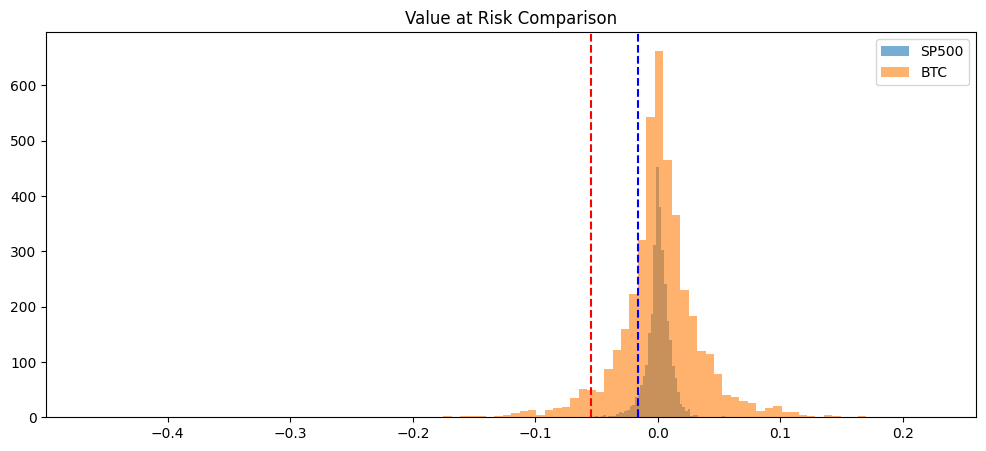

In [11]:
plt.figure(figsize=(12,5))

plt.hist(sp500["log_return"], bins=100, alpha=0.6, label="SP500")
plt.axvline(sp500_var, color="blue", linestyle="--")

plt.hist(btc["log_return"], bins=100, alpha=0.6, label="BTC")
plt.axvline(btc_var, color="red", linestyle="--")

plt.legend()

plt.title("Value at Risk Comparison")

plt.show()

## Value at Risk Interpretation

BTC exhibits significantly larger downside risk compared to SP500.

The wider left tail in BTC indicates higher probability of extreme negative returns.

This reflects the higher uncertainty and speculative nature of cryptocurrency markets.

In [12]:
rolling_var = (
    sp500["log_return"]
    .rolling(30)
    .quantile(0.05)
)

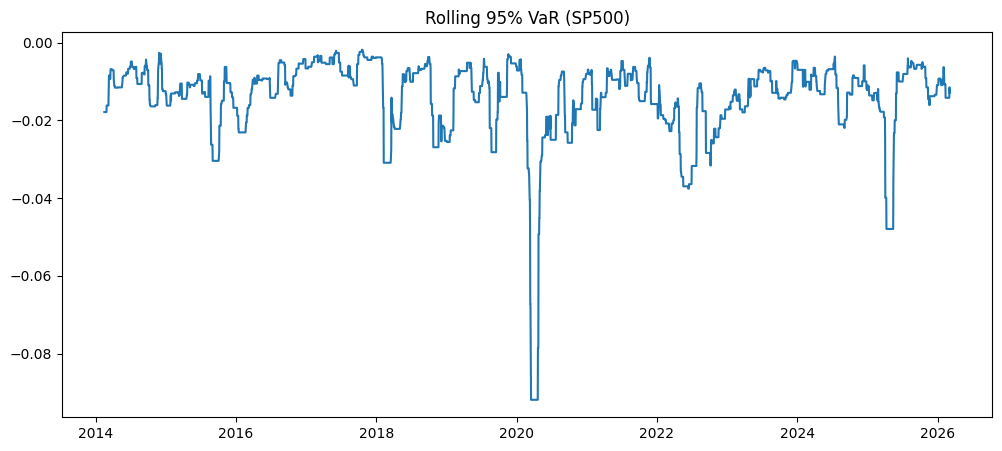

In [13]:
plt.figure(figsize=(12,5))

plt.plot(rolling_var)

plt.title("Rolling 95% VaR (SP500)")

plt.show()

In [14]:
sp500_cvar = sp500["log_return"][
    sp500["log_return"] <= sp500_var
].mean()

btc_cvar = btc["log_return"][
    btc["log_return"] <= btc_var
].mean()

print("SP500 CVaR:", sp500_cvar)
print("BTC CVaR:", btc_cvar)

SP500 CVaR: -0.026736771876962894
BTC CVaR: -0.08654412252259393


## Expected Shortfall Interpretation

CVaR captures the severity of losses during extreme downside events.

BTC exhibits substantially larger expected shortfall, indicating greater tail risk exposure.